In [1]:
import os

import cupy as cp
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
num_devices = cp.cuda.runtime.getDeviceCount()
print(f"Total available devices: {num_devices}\n")

for device_id in range(num_devices):
    with cp.cuda.Device(device_id) as dev:
        props = cp.cuda.runtime.getDeviceProperties(device_id)
        name = props['name'].decode('utf-8')
        cc = dev.compute_capability
        print(f"Device {device_id}: {name}")
        print(f"  - Compute Capability: {cc}")

Total available devices: 1

Device 0: NVIDIA GeForce GTX 1060 6GB
  - Compute Capability: 61


## Overall distribution of data in the GPU

Threads: always set to the maximum of 1024 (pixels at once).\
Blocks: the remaining pixels will be distributed across different blocks, always in X to ease the process

Using the `height_index` we can distinguish which line to apply the transformation

---

In [21]:
kernel = r"""
extern "C"{
    __global__ void dtw2(
                    const float* input, 
                    unsigned int* out, 
                    const unsigned int width, 
                    const unsigned int height
    ){
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        unsigned int width_index = global_index % width;   // internal array
        unsigned int height_index = global_index / width;  // external array (height/y)
    
        if(height_index >= height-1 || width_index >= width-1)
            return;

        // auxiliars
        unsigned int half_width = width/2;
        unsigned int half_height = height/2;

        unsigned int curr_arr_index = (height_index*width) + width_index;
        unsigned int next_col_index = curr_arr_index + 1;
        unsigned int next_row_index = ((height_index+1)*width) + width_index;
        unsigned int next_row_col_index = next_row_index + 1;
        
        unsigned int A_val = 0.5 * ((input[curr_arr_index] + input[next_col_index]) + (input[next_row_index] + input[next_row_col_index]));
        unsigned int B_val = 0.5 * ((input[curr_arr_index] - input[next_col_index]) + (input[next_row_index] - input[next_row_col_index]));
        unsigned int C_val = 0.5 * ((input[curr_arr_index] + input[next_col_index]) - (input[next_row_index] - input[next_row_col_index]));
        unsigned int D_val = 0.5 * ((input[curr_arr_index] - input[next_col_index]) - (input[next_row_index] + input[next_row_col_index]));
        
        unsigned int base_new_remap_index_w = width_index/2;
        unsigned int base_new_remap_index_h = height_index/2;

        unsigned int remaining_in_w = width_index-half_width;
        unsigned int remaining_in_h = height_index-half_height;
        
        atomicAdd(&out[(base_new_remap_index_h * width) + base_new_remap_index_w], A_val);
        atomicAdd(&out[(base_new_remap_index_h * width) + base_new_remap_index_w + half_width + remaining_in_w], B_val);
        atomicAdd(&out[((base_new_remap_index_h+half_height+remaining_in_h) * width) + base_new_remap_index_w], C_val);
        atomicAdd(&out[((base_new_remap_index_h+half_height+remaining_in_h) * width) + base_new_remap_index_w + half_width + remaining_in_w], D_val);
    }
};
"""
dtw2 = cp.RawKernel(kernel, "dtw2")


Shape:  (1024, 256)
pad image:  (256, 1024)


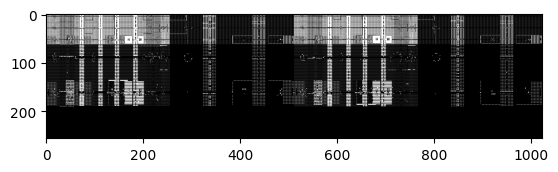

In [26]:
oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')

target_w = 1024
target_h = 256

left = (oimg.width - target_w) // 2
top = (oimg.height - target_h) // 2
right = left + target_w
bottom = top + target_h

cropped = oimg.crop((left, top, right, bottom))

print("Shape: ", cropped.size)

ex_img = cp.asarray(cropped)/255.0
print("pad image: ", ex_img.shape)

out = cp.zeros((256,1024))

dtw2((256,), (1024,), (ex_img, out, 1024, 256))

plt.imshow(out.get(), cmap="grey")
plt.show()